##### Import main libraries

In [ ]:
# !pip install tensorflow

In [1]:
import os
import glob
import fnmatch
import pandas as pd
import numpy as np
import librosa #To deal with Audio files
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
import math
import tensorflow as tf


from keras.layers import concatenate
from keras.models import Sequential, Model, load_model

from keras.layers import Conv1D, Conv2D, SeparableConv1D, MaxPooling1D, MaxPooling2D
from keras.layers import Input, add, Flatten, Dense, BatchNormalization, Dropout, LSTM, GRU
from keras.layers import GlobalMaxPooling1D, GlobalMaxPooling2D, Activation, LeakyReLU, ReLU

from keras import regularizers
from keras import backend as K
from keras.optimizers import Adamax
from keras.callbacks import ModelCheckpoint, EarlyStopping


from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import cohen_kappa_score,roc_auc_score,confusion_matrix,classification_report

In [37]:
os.chdir(r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound")

In [38]:
data_path = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound"
print(os.listdir(data_path))

['artifact', 'extrahls', 'extrastole', 'murmur', 'normal', 'unlabel', 'Graph', 'bilstm_rnn_log.csv', 'bigru_cnn_log.csv', 'checks', 'bigru_rnn_log.csv']


In [39]:
tarin_data      = data_path 
unlabel_data    = data_path  + "/unlabel/"

normal_data     = tarin_data + '/normal/'
murmur_data     = tarin_data + '/murmur/'
extrastole_data = tarin_data + '/extrastole/'
artifact_data   = tarin_data + '/artifact/'
extrahls_data   = tarin_data + "/extrahls/"

In [40]:
print("Normal files:", len(os.listdir(normal_data))) #length of normal training sounds
print("Murmur files:",len(os.listdir(murmur_data))) #length of murmur training sounds 
print("Extrastole files", len(os.listdir(extrastole_data))) #length of extrastole training sounds 
print("Artifact files:",len(os.listdir(artifact_data))) #length of artifact training sounds 
print("Extrahls files:",len(os.listdir(extrahls_data))) #length of extrahls training sounds 

print('TOTAL TRAIN SOUNDS:', len(os.listdir(normal_data)) 
                              + len(os.listdir(murmur_data))
                              + len(os.listdir(extrastole_data))
                              + len(os.listdir(artifact_data))
                              + len(os.listdir(extrahls_data)))

Normal files: 351
Murmur files: 129
Extrastole files 46
Artifact files: 40
Extrahls files: 19
TOTAL TRAIN SOUNDS: 585


In [41]:
print("Test sounds: ", len(os.listdir(unlabel_data)))

Test sounds:  247


# EDA and Visualization

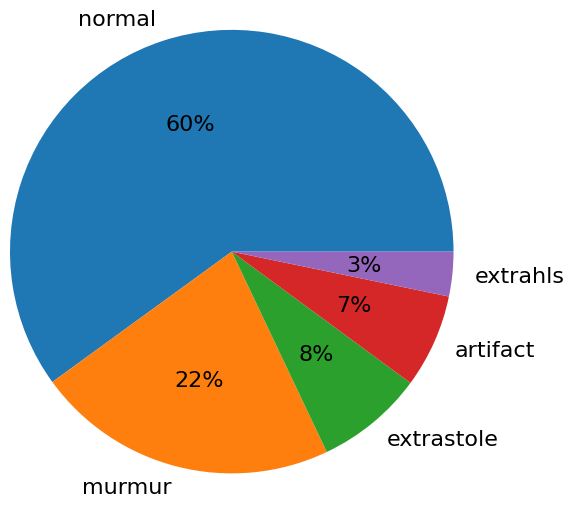

In [42]:
try:
    x = np.array([len(os.listdir(normal_data)),
                  len(os.listdir(murmur_data)),
                  len(os.listdir(extrastole_data)),
                  len(os.listdir(artifact_data)),
                  len(os.listdir(extrahls_data))])
    labels = ['normal', 'murmur', 'extrastole', 'artifact', 'extrahls']
    plt.pie(x, labels = labels, autopct = '%.0f%%', radius= 1.5, textprops={'fontsize': 16})
    plt.show()
except:
    pass

##### The figure shows imbalanced data so we need to fix it later 


In [43]:
# Listen to rondom audio from specific class
def random_sound (audio_class):
    print(audio_class)
    random_sound = np.random.randint(0,len(os.listdir(audio_class))) 
    sound = os.listdir(audio_class)[random_sound]
    sound = audio_class+sound
    sound,sample_rate = librosa.load(sound)
    return ipd.Audio(sound,rate=sample_rate),sound

### Waveform

Sound is the pressure of air propagates to our ear. Digital audio file is gotten from a sound sensor that can detects sound waves and converting it to electrical signals.
Specifically, it's telling us about the wave's displacement, and how it changes over time.



X axis, represents time.
Y-axis measures displacement of air molecules.This is where amplitude comes in. It measures how much a molecule is displaced from its resting position.  

In [44]:
def show_audio_waveform(audio_sample, sr=22050):
    times = np.arange(len(audio_sample)) / sr
    plt.figure(figsize=(20,5))
    plt.plot(times, audio_sample)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("Heartbeat Waveform")
    plt.show()

### Spectrum

A sound spectrum is a representation of a sound – usually a short sample of a sound – in terms of the amount of vibration at each individual frequency. It is usually presented as a graph of either power or pressure as a function of frequency. The power or pressure is usually measured in decibels and the frequency is measured in vibrations per second (or hertz, abbreviation Hz) or thousands of vibrations per second (kilohertz, abbreviation kHz).

The spectrum expresses the frequency composition of the sound and is obtained by analyzing the sound. A sound spectrum is usually represented in a coordinate plane where the frequency f is plotted along the axis of abscissas and the amplitude A, or intensity, of a harmonic component with a given frequency is plotted along the axis of ordinates.

In [45]:
# show spectrum of audio from dataset 
def show_audio_spectrum(audio_sample):
    sample_rate = 22050
    fft_normal = np.fft.fft(audio_sample)
    magnitude_normal = np.abs(fft_normal)
    freq_normal = np.linspace(0,sample_rate, len(magnitude_normal)) 
    half_freq = freq_normal[:int(len(freq_normal)/2)]
    half_magnitude = magnitude_normal[:int(len(freq_normal)/2)]

    plt.figure(figsize=(12,8))
    plt.plot(half_freq,half_magnitude)
    plt.title("Spectrum")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.show()

### Spectogram

For us, as human, we sense a sound not only on a particular time by its intensity, but also by its pitch. The pitch is the frequency of the sound - higher pitch corresponding to higher frequency and vice versa. So, to have a representation which is closer to our brain, we can add another dimension - the frequency - to our representation, which is the Spectrogram.

A spectrogram is a visual representation of the spectrum of frequencies of a signal as it varies with time. When applied to an audio signal, spectrograms are sometimes called sonographs, voiceprints, or voicegrams.

Spectrograms are used extensively in the fields of music, linguistics, sonar, radar, speech processing,seismology, and others. Spectrograms of audio can be used to identify spoken words phonetically, and to analyse the various calls of animals.it can be generated by an optical spectrometer, a bank of band-pass filters, by Fourier transform or by a wavelet transform.

In [46]:
# show specrogram of audio from dataset 
# the output is an image that represents a sound. 
# X-axis is for time, y-axis is for frequency and the color is for intensity
def show_spectrogram (audio_sample):    
    # STFT -> spectrogram
    hop_length = 512 # in num. of samples
    n_fft = 2048 # window in num. of samples
    sample_rate = 22050

    # calculate duration hop length and window in seconds
    hop_length_duration = float(hop_length)/sample_rate
    n_fft_duration = float(n_fft)/sample_rate

    print("STFT hop length duration is: {}s".format(hop_length_duration))
    print("STFT window duration is: {}s".format(n_fft_duration))

    # perform stft
    stft_normal = librosa.stft(audio_sample, n_fft=n_fft, hop_length=hop_length)

    # calculate abs values on complex numbers to get magnitude
    spectrogram = np.abs(stft_normal)
    log_spectrogram = librosa.amplitude_to_db(spectrogram)

    # display spectrogram
    plt.figure(figsize=(15,10))
    librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar()
    #plt.set_cmap("YlOrBr")
    plt.title("Spectrogram")

### MFCCs

We can’t take the raw audio signal as input to our model because there will be a lot of noise in the audio signal. It is observed that extracting features from the audio signal and using it as input to the base model will produce much better performance than directly considering raw audio signal as input. MFCC is the widely used technique for extracting the features from the audio signal.

in sound processing, the mel-frequency cepstrum (MFC) is a representation of the short-term power spectrum of a sound, based on a linear cosine transform of a log power spectrum on a nonlinear mel scale of frequency.

Mel-frequency cepstral coefficients (MFCCs) are coefficients that collectively make up an MFC. They are derived from a type of cepstral representation of the audio clip (a nonlinear "spectrum-of-a-spectrum"). The difference between the cepstrum and the mel-frequency cepstrum is that in the MFC, the frequency bands are equally spaced on the mel scale, which approximates the human auditory system's response more closely than the linearly-spaced frequency bands used in the normal spectrum. This frequency warping can allow for better representation of sound, for example, in audio compression.

**MFCCs are commonly derived as follows:**

1- Take the Fourier transform of (a windowed excerpt of) a signal.

2- Map the powers of the spectrum obtained above onto the mel scale, using triangular overlapping windows or alternatively, cosine overlapping windows.

3- Take the logs of the powers at each of the mel frequencies.

4- Take the discrete cosine transform of the list of mel log powers, as if it were a signal.

5- The MFCCs are the amplitudes of the resulting spectrum.

In [47]:
import matplotlib.pyplot as plt
import librosa.display

def show_mfcc_features(audio_sample):
    hop_length = 512 # in num. of samples
    n_fft = 2048 # window in num. of samples
    sample_rate = 22050
    
    MFCCs = librosa.feature.mfcc(y=audio_sample, sr=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mfcc=52)

    # display MFCCs
    plt.figure(figsize=(15,10))
    librosa.display.specshow(MFCCs, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("MFCC coefficients")
    plt.colorbar()
    plt.title("MFCCs")
    plt.show()


##  Dataset Classes

### *1. Normal* 

Most normal heart rates at rest
will be between about 60 and
100 beats (‘lub dub’s) per
minute. 

In [48]:
normal_audio, normal_sample  = random_sound(normal_data)
normal_audio

G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/normal/


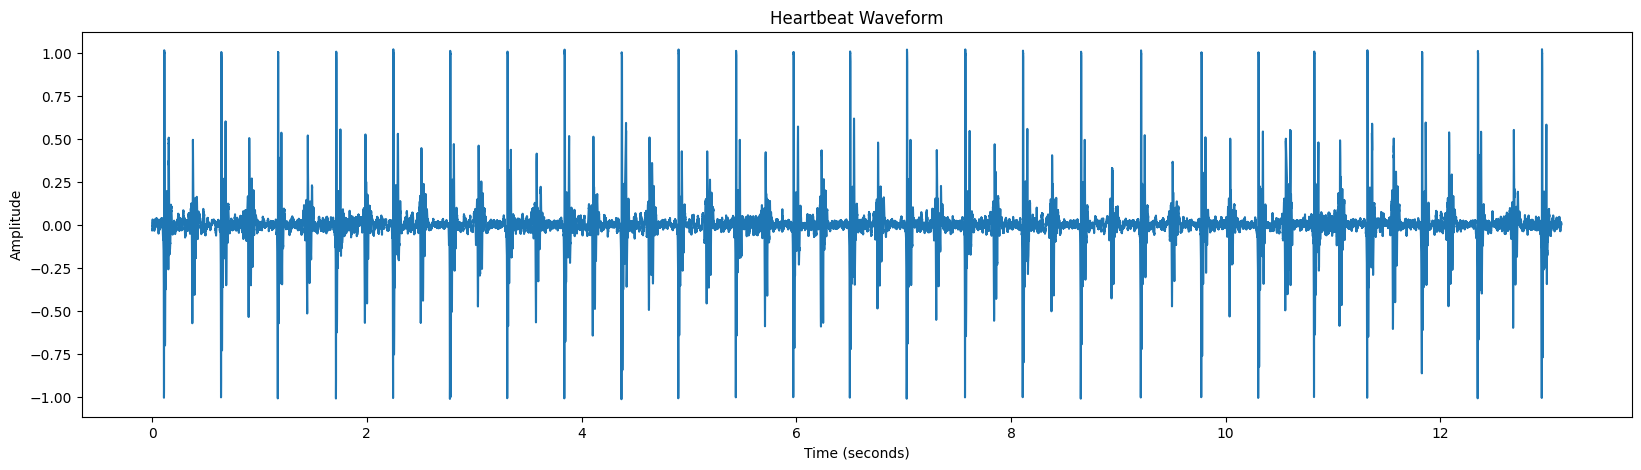

In [49]:
show_audio_waveform(normal_sample)

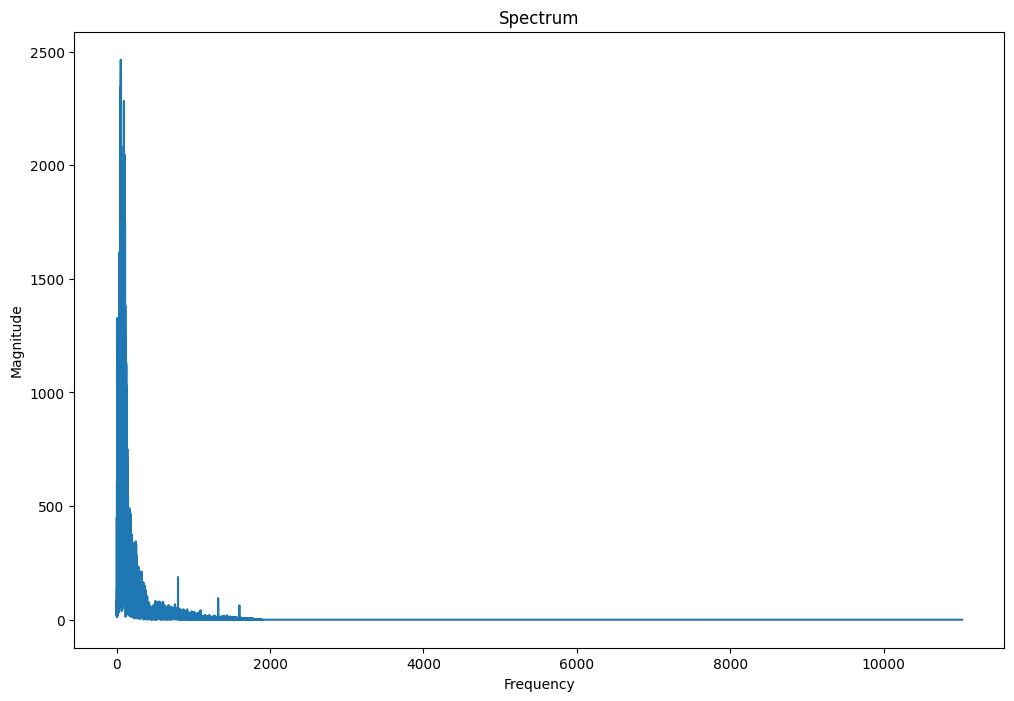

In [50]:
show_audio_spectrum(normal_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


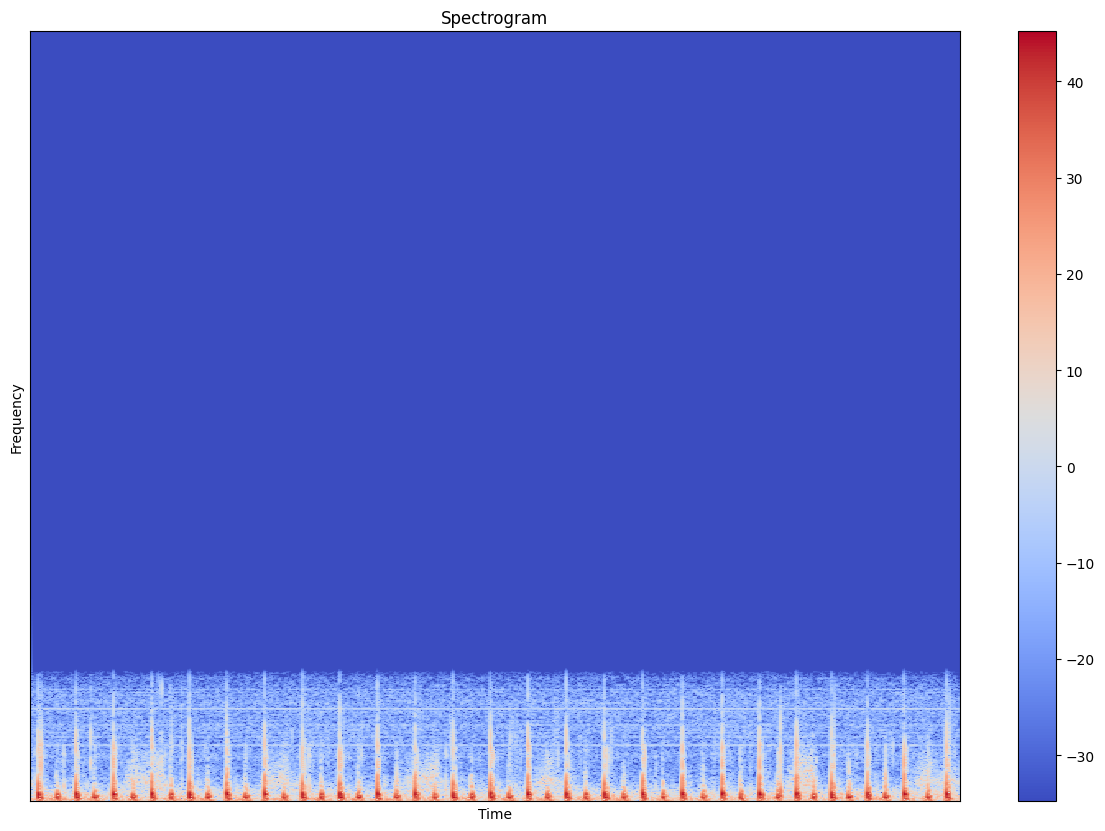

In [51]:
show_spectrogram(normal_sample)

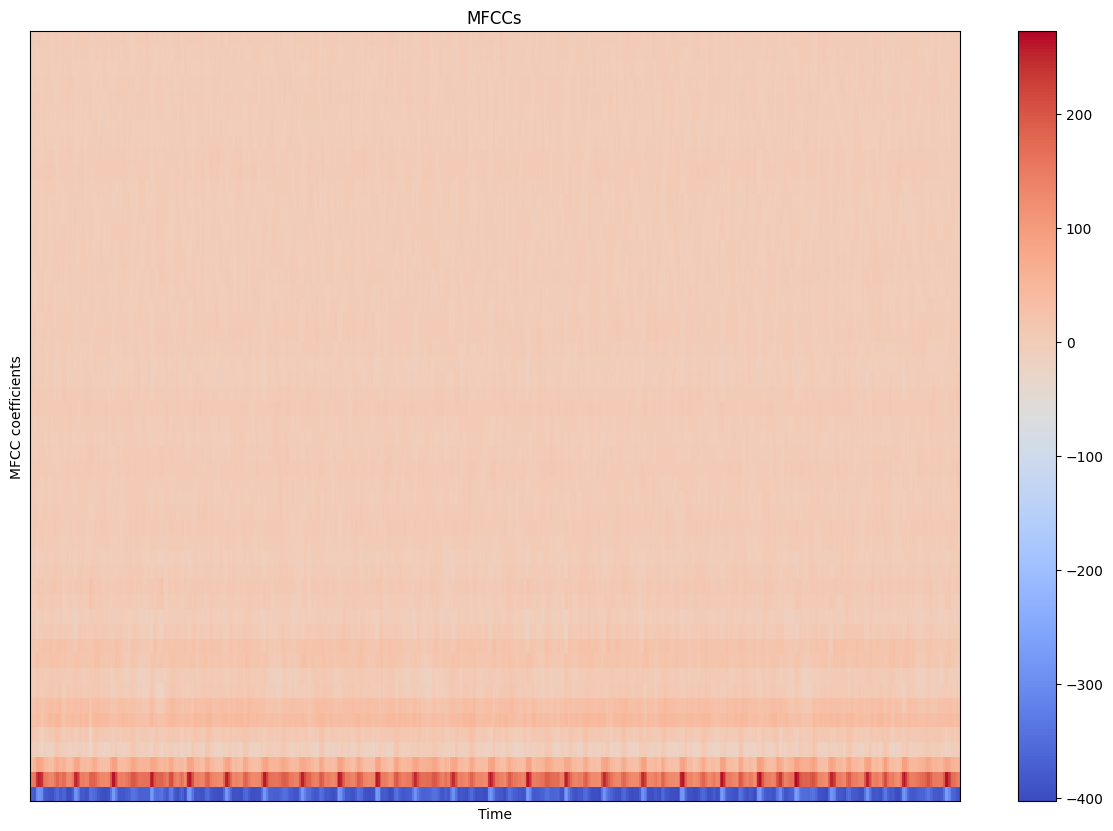

In [52]:
show_mfcc_features(normal_sample)

### *2. Murmur sound*

Heart murmurs sound as though there
is a “whooshing, roaring, rumbling, or
turbulent fluid” noise in one of two
temporal locations: (1) between “lub”
and “dub”, or (2) between “dub” and
“lub”. They can be a symptom of many
heart disorders, some serious. 

In [53]:
murmur_audio, murmur_sample  = random_sound(murmur_data)
murmur_audio

G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/murmur/


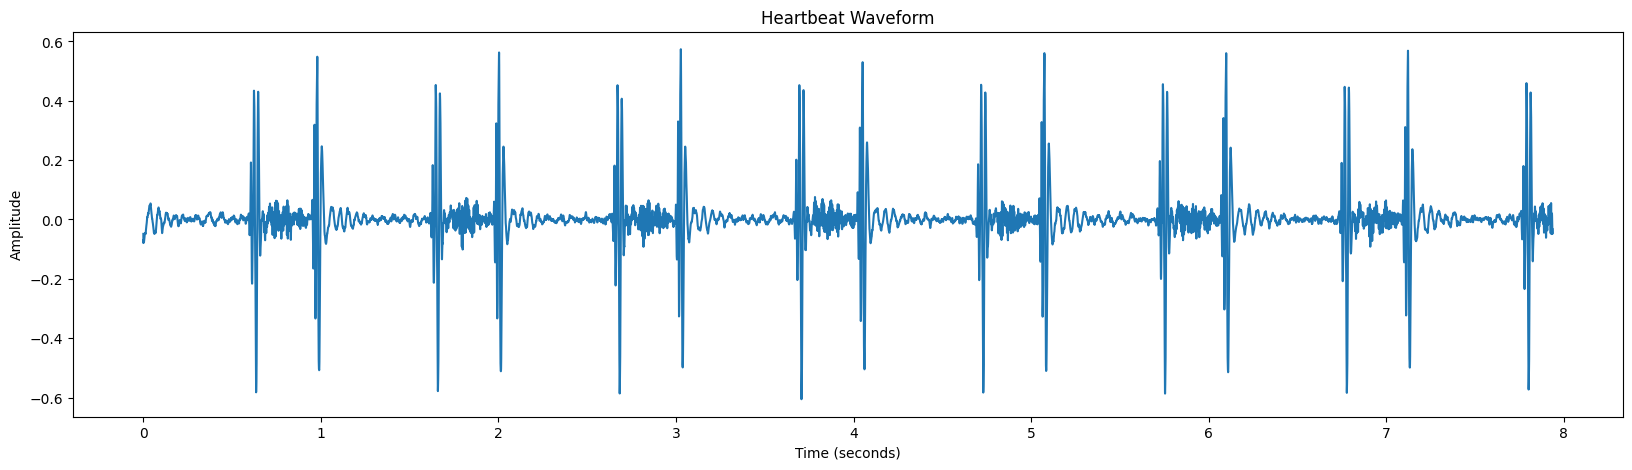

In [54]:
show_audio_waveform(murmur_sample)

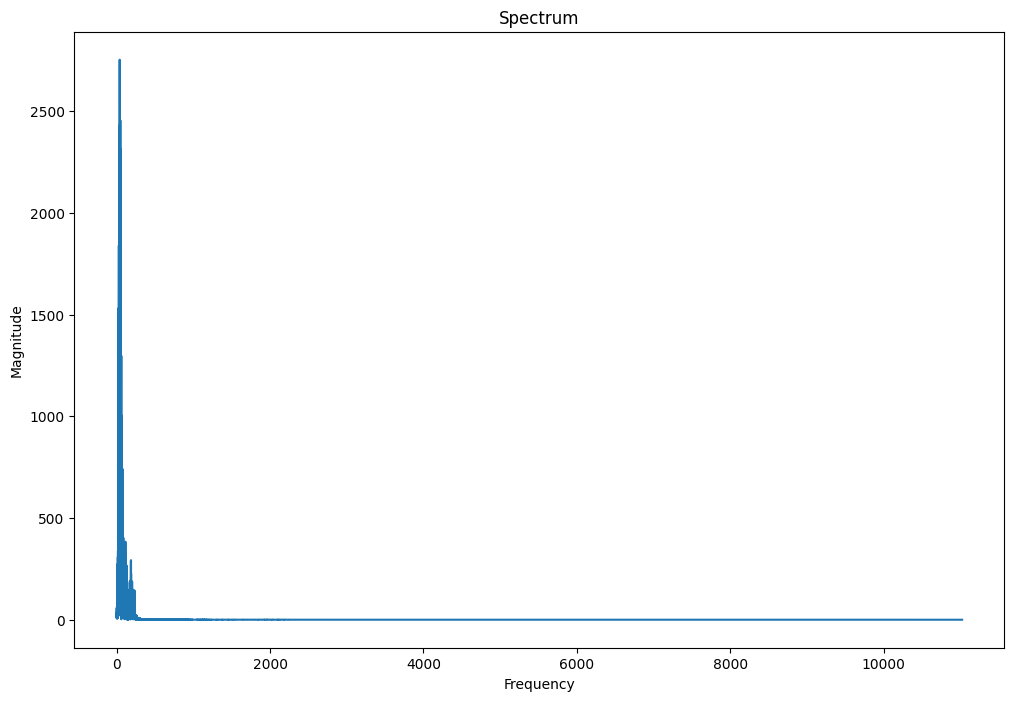

In [55]:
show_audio_spectrum(murmur_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


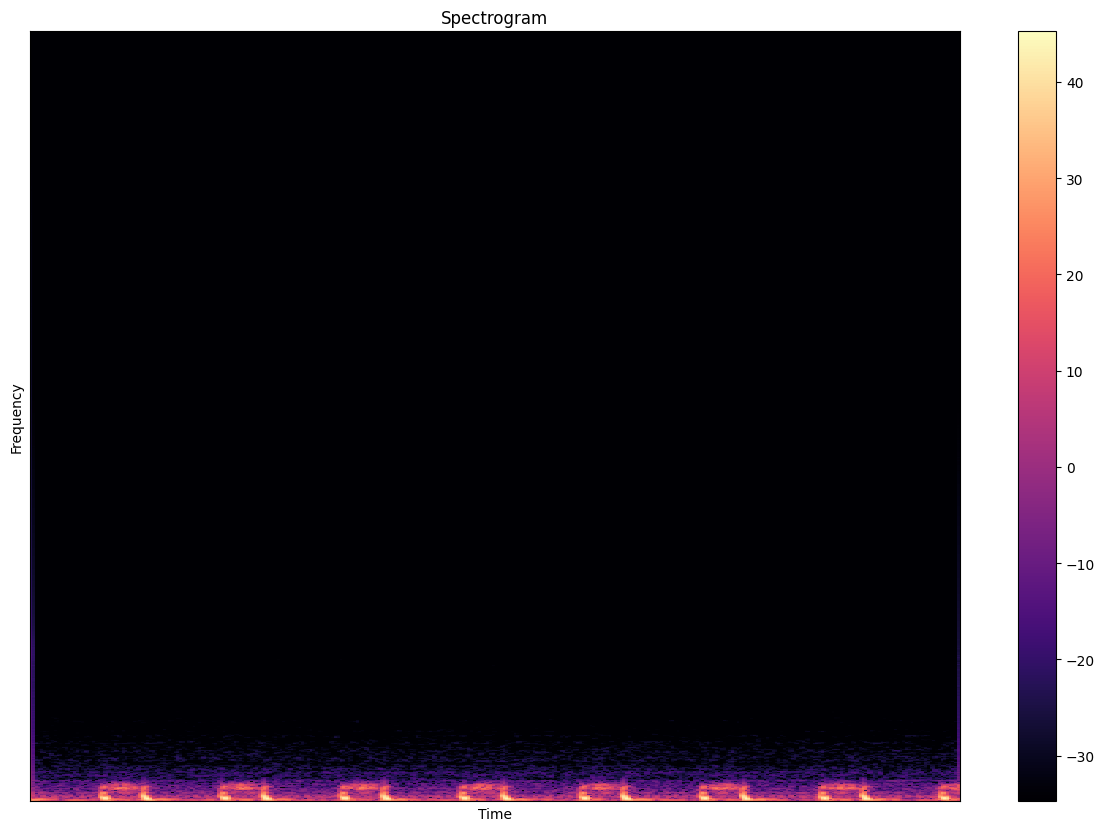

In [56]:
show_spectrogram(murmur_sample)

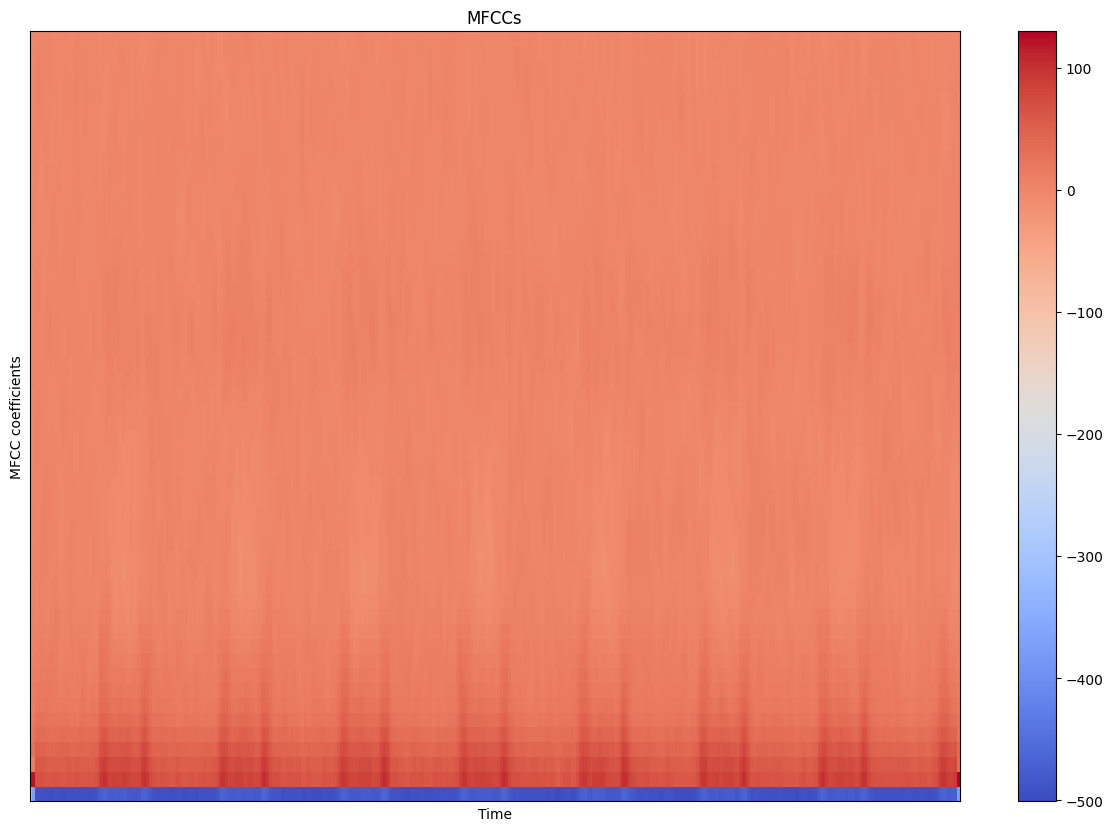

In [57]:
show_mfcc_features(murmur_sample)

### *3. Extrastole sound*

• Extrasystole sounds may appear occasionally and can be
identified because there is a heart sound that is out of rhythm
involving extra or skipped heartbeats, e.g. a “lub-lub dub” or a
“lub dub-dub”.

In [58]:
extrastole_audio, extrastole_sample  = random_sound(extrastole_data)
extrastole_audio

G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/extrastole/


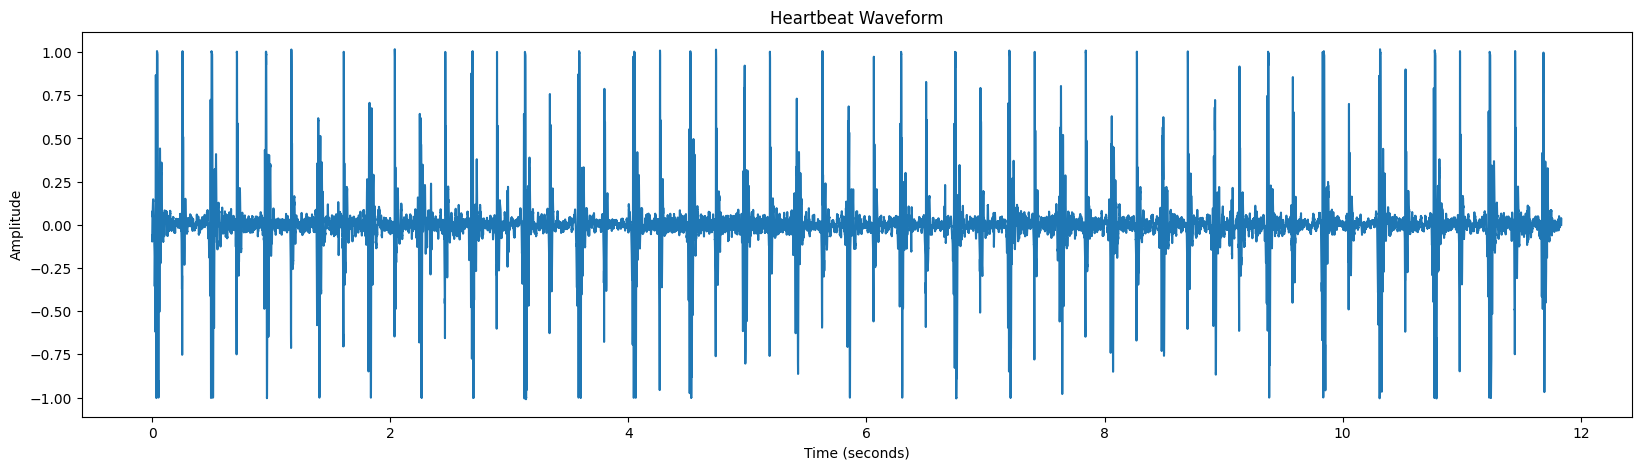

In [59]:
show_audio_waveform(extrastole_sample)

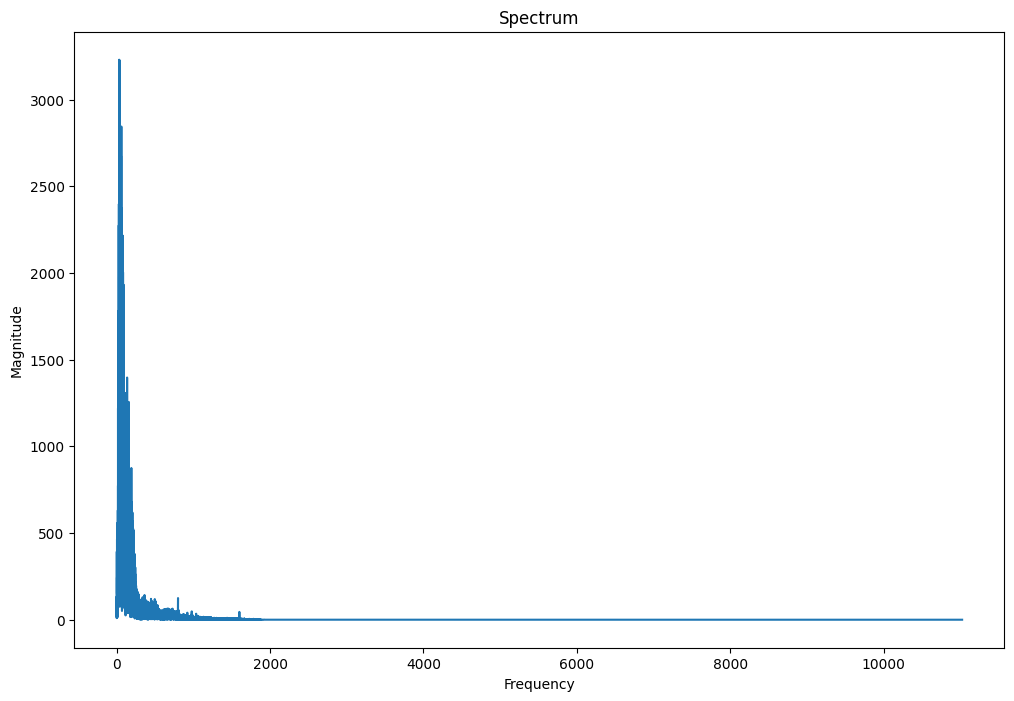

In [60]:
show_audio_spectrum(extrastole_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


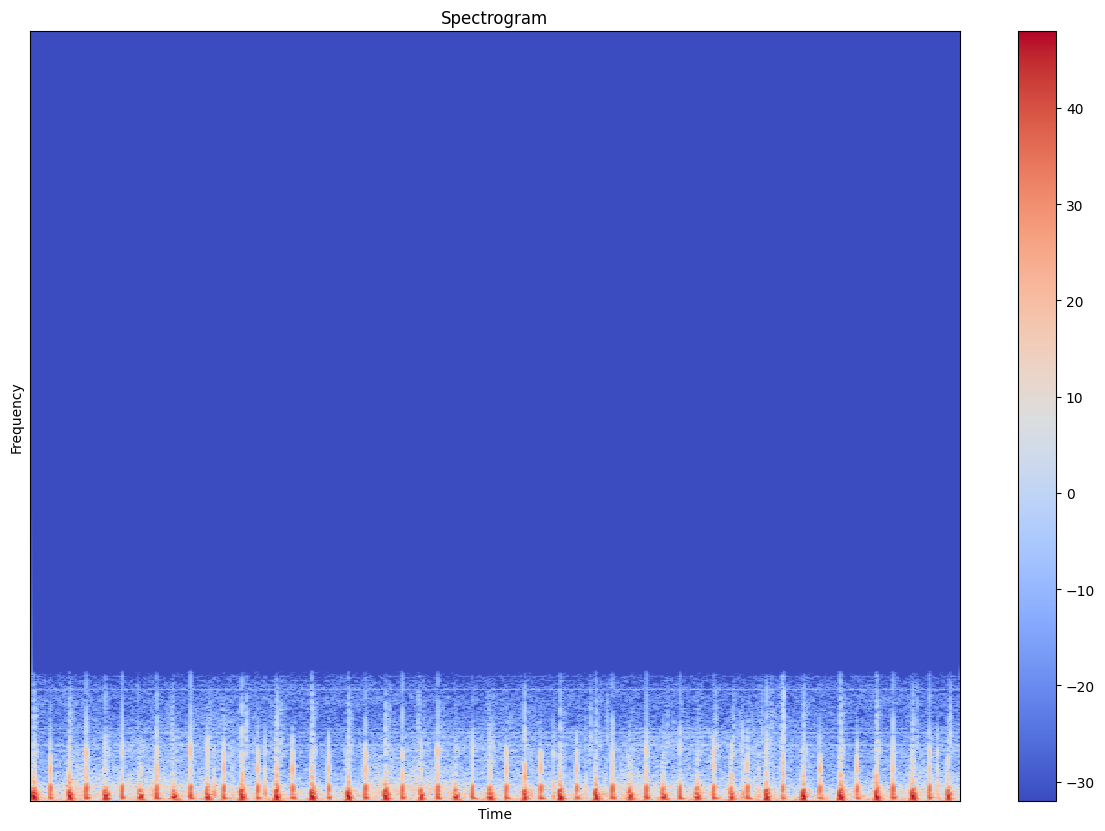

In [61]:
show_spectrogram(extrastole_sample)

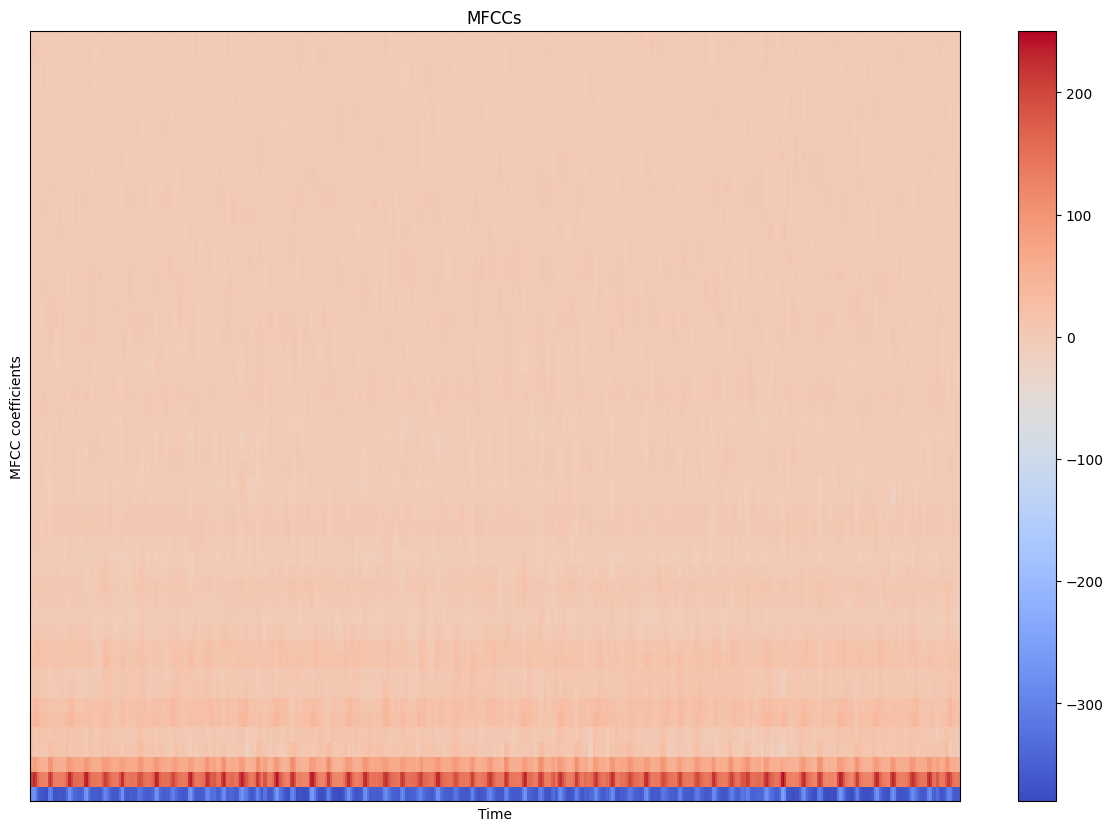

In [62]:
show_mfcc_features(extrastole_sample)

### *4. Artifact sound*

• In the Artifact category there are a wide range of different
sounds, including feedback squeals and echoes, speech, music
and noise.

In [63]:
artifact_audio, artifact_sample  = random_sound(artifact_data)
artifact_audio

G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/artifact/


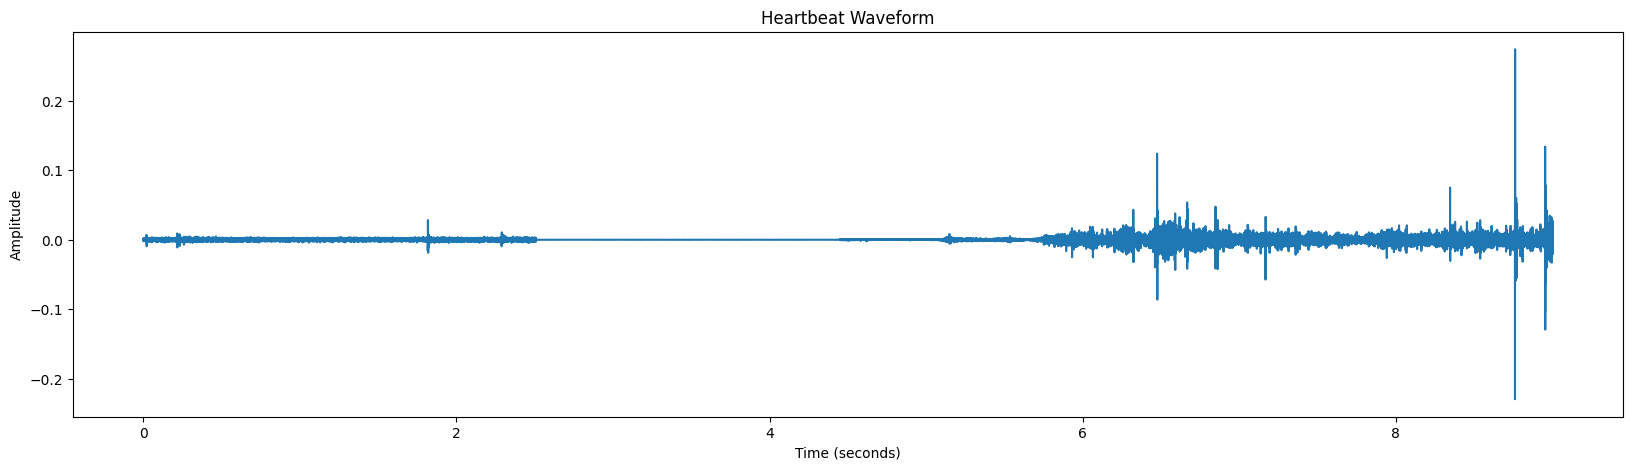

In [64]:
show_audio_waveform(artifact_sample)

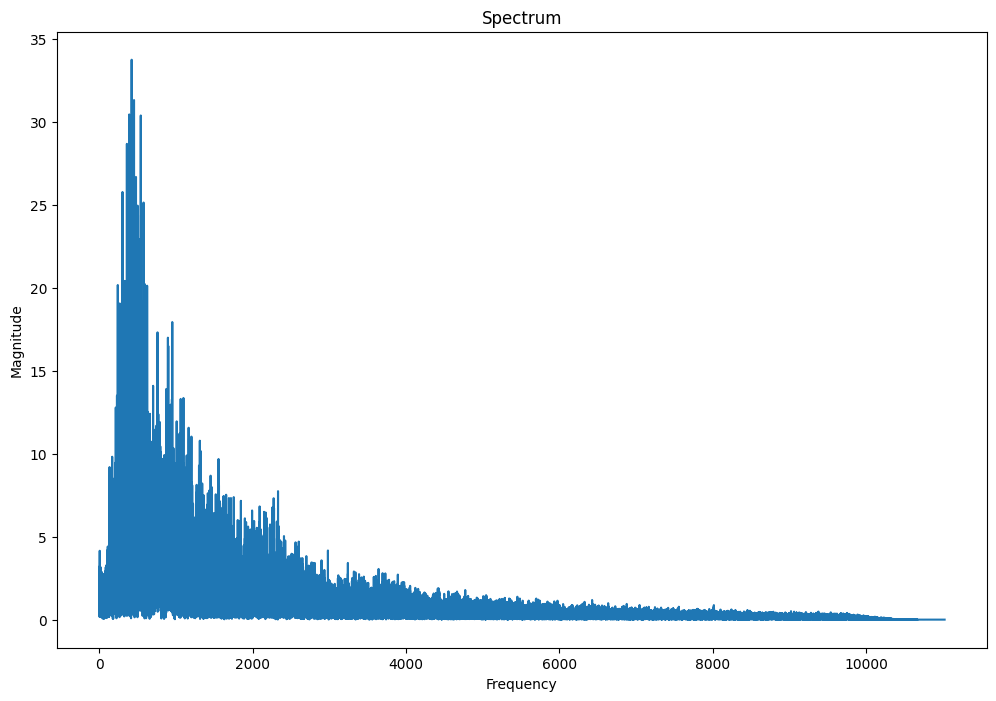

In [65]:
show_audio_spectrum(artifact_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


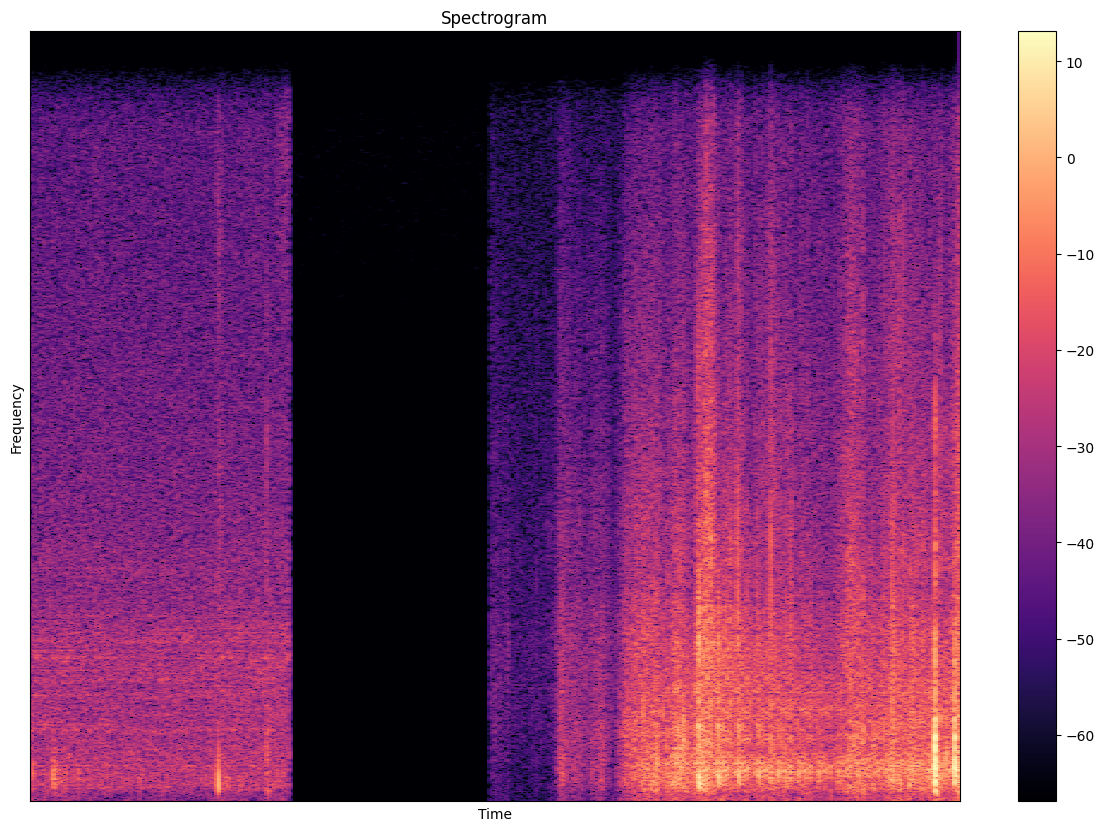

In [66]:
show_spectrogram(artifact_sample)

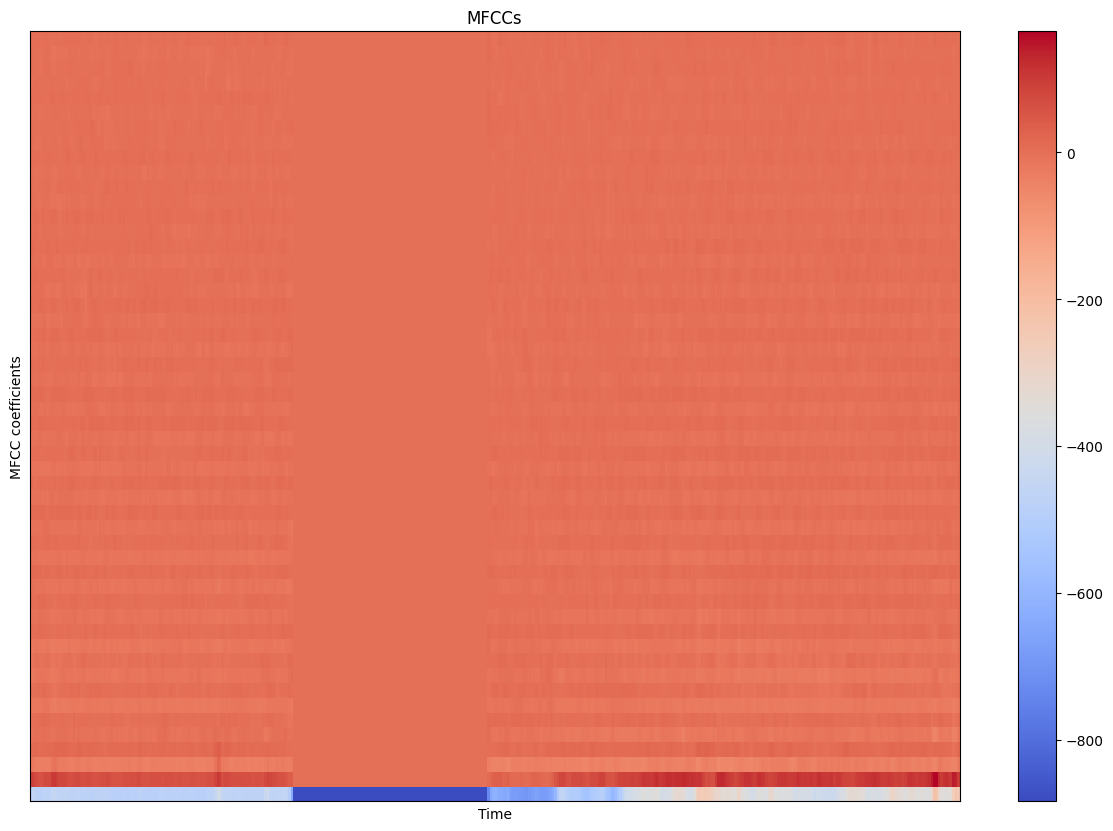

In [67]:
show_mfcc_features(artifact_sample)

### *5. Extrahls sound*

Extra heart sounds can be identified because there is an
additional sound, e.g. a “lub-lub dub” or a “lub dub-dub”. 

In [68]:
extrahls_audio, extrahls_sample  = random_sound(extrahls_data)
extrahls_audio

G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/extrahls/


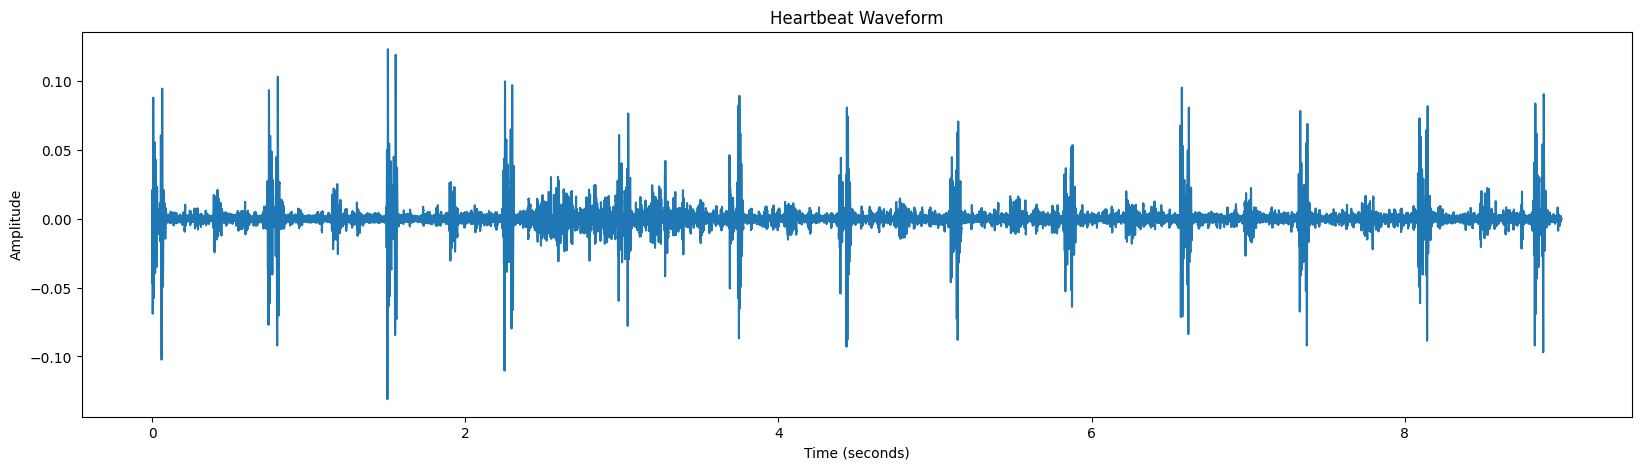

In [69]:
show_audio_waveform(extrahls_sample)

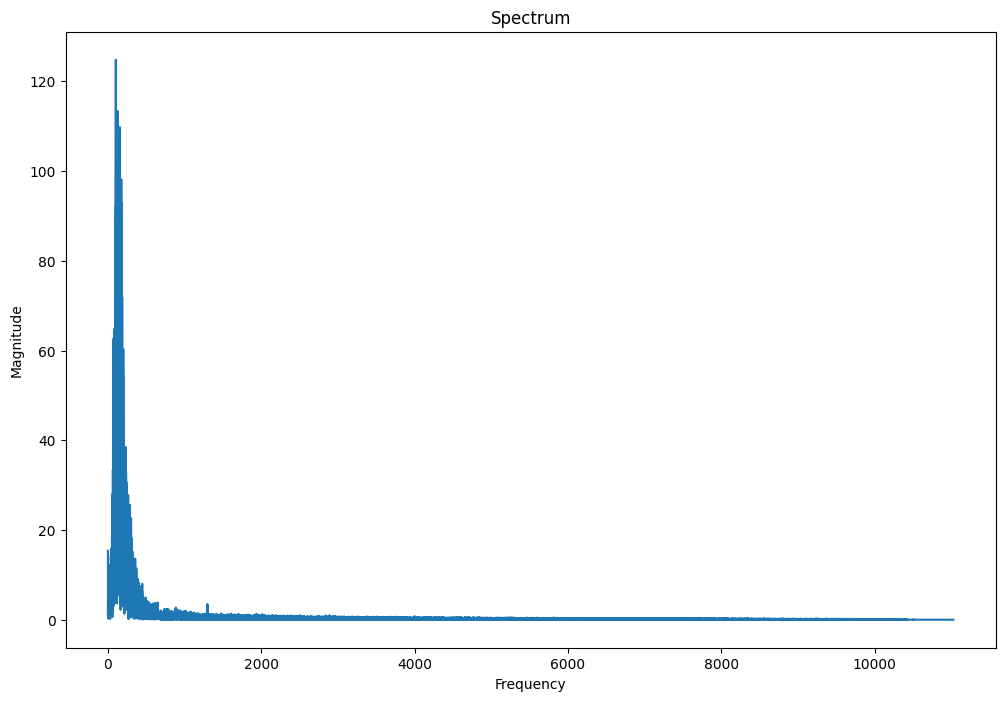

In [70]:
show_audio_spectrum(extrahls_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


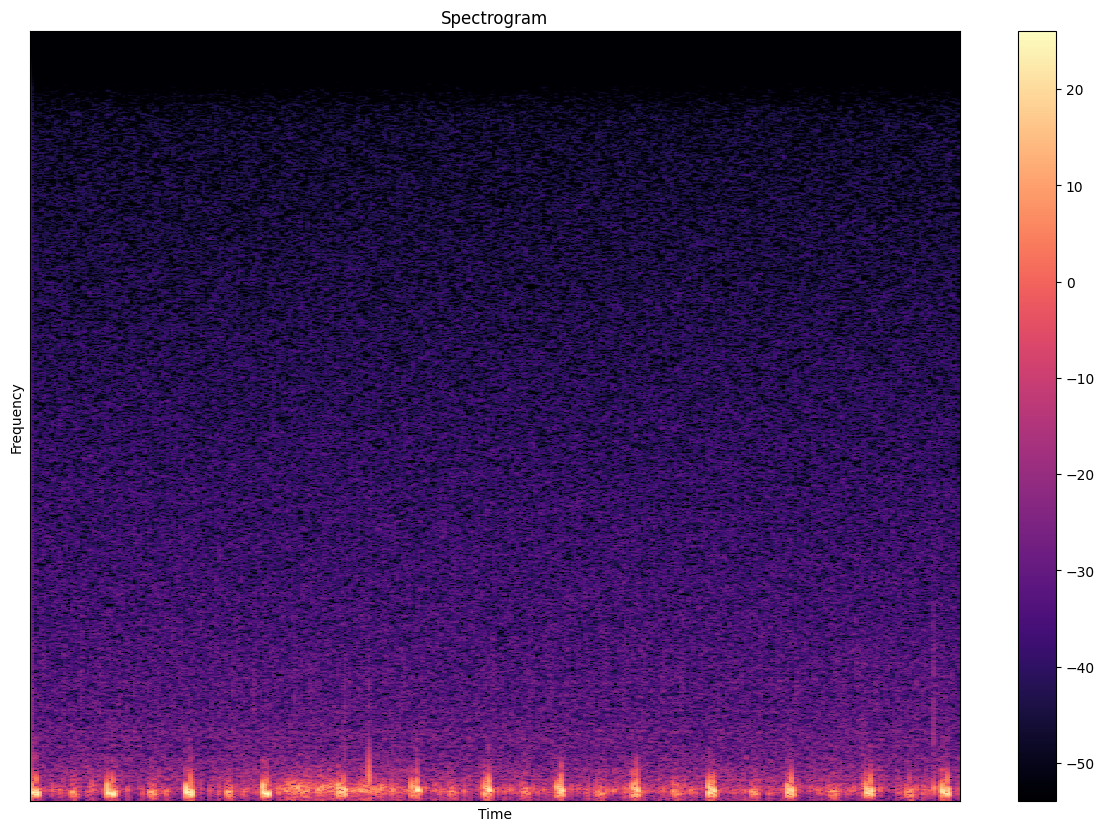

In [71]:
show_spectrogram(extrahls_sample)

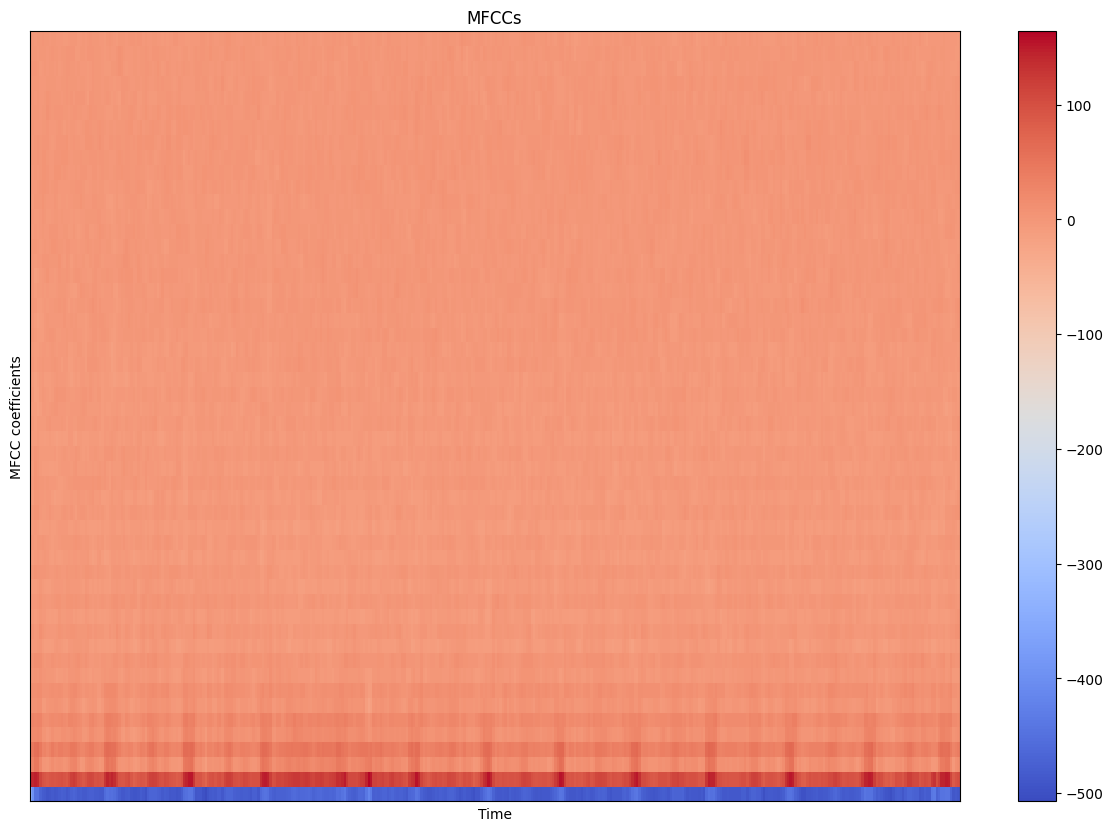

In [72]:
show_mfcc_features(extrahls_sample)

# Data Preprocessing

In [18]:
def add_noise(data,x):
    noise = np.random.randn(len(data))
    data_noise = data + x * noise
    return data_noise

def shift(data,x):
    return np.roll(data, x)

def stretch(data, rate):
    data = librosa.effects.time_stretch(data, rate)
    return data

def pitch_shift (data , rate):
    data = librosa.effects.pitch_shift(data, sr=220250, n_steps=rate)
    return data

In [19]:
def load_file_data (folder, file_names, duration=10, sr=22050):
    '''
        Extract MFCC feature from the Sound data from the audio data. 
        Augmentation of sound data by adding Noise, streaching and shifting.
        52 features are extracted from each audio data and used to train the model.
        
        Args: 
            dir_: Input directory to the Sound input file.
        
        Returns:
            data: list of features extracted from the sound file.
    '''
    input_length=sr*duration
    features = 52
    data = []
    for file_name in file_names:
       
            sound_file = folder+file_name
            X, sr = librosa.load( sound_file, sr=sr, duration=duration) 
            dur = librosa.get_duration(y=X, sr=sr)
            # pad audio file same duration
            if (round(dur) < duration):
                print ("fixing audio lenght :", file_name)
                X = librosa.util.fix_length(X, input_length)  
                
            # extract normalized mfcc feature from data
            mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sr, n_mfcc=features).T,axis=0) 
            feature = np.array(mfccs).reshape([-1,1])
            data.append(feature)
            
            stretch_data_1 = stretch (X, 0.8)
            mfccs_stretch_1 = np.mean(librosa.feature.mfcc(y=stretch_data_1, sr=sr, n_mfcc=features).T,axis=0) 
            feature_1 = np.array(mfccs_stretch_1).reshape([-1,1])
            data.append(feature_1)
            
            stretch_data_2 = stretch (X, 1.2) 
            mfccs_stretch_2 = np.mean(librosa.feature.mfcc(y=stretch_data_2, sr=sr, n_mfcc=features).T,axis=0) 
            feature_2 = np.array(mfccs_stretch_2).reshape([-1,1])
            data.append(feature_2)
            
           
        
    return data

## Encoding

In [20]:
# simple encoding of categories, convert to only 3 types:
# Normal (Include extrahls and extrastole)
# Murmur
# Artifact

# Map label text to integer
CLASSES = ['artifact','murmur','normal']
NB_CLASSES=len(CLASSES)

# Map integer value to text labels
label_to_int = {k:v for v,k in enumerate(CLASSES)}
print (label_to_int)
print (" ")
int_to_label = {v:k for k,v in label_to_int.items()}
print(int_to_label)

{'artifact': 0, 'murmur': 1, 'normal': 2}
 
{0: 'artifact', 1: 'murmur', 2: 'normal'}


## Data Augmenation and Feature Extraction

In [21]:
import librosa
import numpy as np
import os

# Augmentation: Stretching function
def stretch(data, rate):
    # Correct usage of time_stretch with rate passed as a keyword argument
    stretched_data = librosa.effects.time_stretch(y=data, rate=rate)
    return stretched_data

# Function to load and process the audio files
def load_file_data(folder, file_names, duration=10, sr=22050):
    input_length = sr * duration
    features = 52
    data = []
    
    for file_name in file_names:
        sound_file = os.path.join(folder, file_name)
        
        # Load the audio file
        X, sr = librosa.load(sound_file, sr=sr, duration=duration) 
        
        # Get the duration of the audio file
        dur = librosa.get_duration(y=X, sr=sr)
        
        # Pad or truncate the audio to the same length
        if round(dur) < duration:
            print(f"Fixing audio length: {file_name}")
            X = librosa.util.fix_length(X, size=input_length)  # Fix audio length
        
        # Extract normalized MFCC feature
        mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sr, n_mfcc=features).T, axis=0) 
        data.append(mfccs)
        
        # Augmentation: Stretching with different rates
        stretch_data_1 = stretch(X, 0.8)
        mfccs_stretch_1 = np.mean(librosa.feature.mfcc(y=stretch_data_1, sr=sr, n_mfcc=features).T, axis=0)
        data.append(mfccs_stretch_1)

        stretch_data_2 = stretch(X, 1.2)
        mfccs_stretch_2 = np.mean(librosa.feature.mfcc(y=stretch_data_2, sr=sr, n_mfcc=features).T, axis=0)
        data.append(mfccs_stretch_2)
    
    return data




In [22]:
# Load audio files and process them
artifact_data = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/artifact/"
all_files = os.listdir(artifact_data)

# Filter only files (exclude directories)
only_files = [f for f in all_files if os.path.isfile(os.path.join(artifact_data, f))]
print(only_files)

# Format file names (example: lowercase and replace spaces)
formatted_files = [f.lower().replace(' ', '') for f in only_files]
print(formatted_files)
# Load data with the correct parameters
MAX_SOUND_CLIP_DURATION = 10  # Adjust this based on your needs
artifact_sounds = load_file_data(folder=artifact_data, file_names=formatted_files, duration=MAX_SOUND_CLIP_DURATION)
artifact_labels = [0 for _ in artifact_sounds]

['artifact__201012172012.wav', 'artifact__201105040918.wav', 'artifact__201105041959.wav', 'artifact__201105051017.wav', 'artifact__201105060108.wav', 'artifact__201105061143.wav', 'artifact__201105190800.wav', 'artifact__201105280851.wav', 'artifact__201106010559.wav', 'artifact__201106010602.wav', 'artifact__201106021541.wav', 'artifact__201106030612.wav', 'artifact__201106031558.wav', 'artifact__201106040722.wav', 'artifact__201106040933.wav', 'artifact__201106040947.wav', 'artifact__201106041452.wav', 'artifact__201106050353.wav', 'artifact__201106061233.wav', 'artifact__201106070537.wav', 'artifact__201106070949.wav', 'artifact__201106101314.wav', 'artifact__201106101955.wav', 'artifact__201106110909.wav', 'artifact__201106111119.wav', 'artifact__201106121242.wav', 'artifact__201106121445.wav', 'artifact__201106131834.wav', 'artifact__201106131835.wav', 'artifact__201106141701.wav', 'artifact__201106161016.wav', 'artifact__201106161019.wav', 'artifact__201106161219.wav', 'artifact

In [23]:
# Load audio files and process them
normal_data = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/normal/"
all_files = os.listdir(normal_data)

# Filter only files (exclude directories)
only_files = [f for f in all_files if os.path.isfile(os.path.join(normal_data, f))]
print(only_files)

# Format file names (example: lowercase and replace spaces)
formatted_files = [f.lower().replace(' ', '') for f in only_files]

# Load data with the correct parameters
MAX_SOUND_CLIP_DURATION = 10  # Adjust this based on your needs
normal_sounds = load_file_data(folder=normal_data, file_names=formatted_files, duration=MAX_SOUND_CLIP_DURATION)
normal_labels = [1 for _ in normal_sounds]

['normal_noisynormal_101_1305030823364_B.wav', 'normal_noisynormal_101_1305030823364_E.wav', 'normal_noisynormal_104_1305032492469_A.wav', 'normal_noisynormal_105_1305033453095_A.wav', 'normal_noisynormal_105_1305033453095_C.wav', 'normal_noisynormal_106_1306776721273_A.wav', 'normal_noisynormal_107_1305654946865_A.wav', 'normal_noisynormal_108_1305654420093_A.wav', 'normal_noisynormal_108_1305654420093_B.wav', 'normal_noisynormal_109_1305653646620_A.wav', 'normal_noisynormal_109_1305653972028_A.wav', 'normal_noisynormal_109_1305653972028_C.wav', 'normal_noisynormal_109_1305653972028_E.wav', 'normal_noisynormal_109_1305653972028_F.wav', 'normal_noisynormal_110_1305655332337_A.wav', 'normal_noisynormal_110_1305655332337_B.wav', 'normal_noisynormal_113_1306244002866_A.wav', 'normal_noisynormal_113_1306244002866_B.wav', 'normal_noisynormal_115_1306259437619_A1.wav', 'normal_noisynormal_115_1306259437619_B.wav', 'normal_noisynormal_117_1306262456650_A.wav', 'normal_noisynormal_117_13062624

In [24]:
# Load audio files and process them
extrahls_data = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/extrahls/"
all_files = os.listdir(extrahls_data)

# Filter only files (exclude directories)
only_files = [f for f in all_files if os.path.isfile(os.path.join(extrahls_data, f))]
print(only_files)

# Format file names (example: lowercase and replace spaces)
formatted_files = [f.lower().replace(' ', '') for f in only_files]

# Load data with the correct parameters
MAX_SOUND_CLIP_DURATION = 10  # Adjust this based on your needs
extrahls_sounds = load_file_data(folder=extrahls_data, file_names=formatted_files, duration=MAX_SOUND_CLIP_DURATION)
extrahls_labels = [0 for _ in extrahls_sounds]

['extrahls__201101070953.wav', 'extrahls__201101091153.wav', 'extrahls__201101152255.wav', 'extrahls__201101160804.wav', 'extrahls__201101160808.wav', 'extrahls__201101161027.wav', 'extrahls__201101241423.wav', 'extrahls__201101241433.wav', 'extrahls__201102070251.wav', 'extrahls__201102071835.wav', 'extrahls__201102241217.wav', 'extrahls__201103150114.wav', 'extrahls__201103170134.wav', 'extrahls__201103182227.wav', 'extrahls__201103200218.wav', 'extrahls__201104021355.wav', 'extrahls__201104140118.wav', 'extrahls__201104270458.wav', 'extrahls__201104270459.wav']
Fixing audio length: extrahls__201101070953.wav
Fixing audio length: extrahls__201101091153.wav
Fixing audio length: extrahls__201101152255.wav
Fixing audio length: extrahls__201101160804.wav
Fixing audio length: extrahls__201101160808.wav
Fixing audio length: extrahls__201101161027.wav
Fixing audio length: extrahls__201101241423.wav
Fixing audio length: extrahls__201101241433.wav
Fixing audio length: extrahls__201102070251.w

In [25]:
# Load audio files and process them
extrastole_data = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound//extrastole/"
all_files = os.listdir(extrastole_data)

# Filter only files (exclude directories)
only_files = [f for f in all_files if os.path.isfile(os.path.join(extrastole_data, f))]
print(only_files)

# Format file names (example: lowercase and replace spaces)
formatted_files = [f.lower().replace(' ', '') for f in only_files]

# Load data with the correct parameters
MAX_SOUND_CLIP_DURATION = 10  # Adjust this based on your needs
extrastole_sounds = load_file_data(folder=extrastole_data, file_names=formatted_files, duration=MAX_SOUND_CLIP_DURATION)
extrastole_labels = [1 for _ in extrastole_sounds]

['extrastole__127_1306764300147_C2.wav', 'extrastole__128_1306344005749_A.wav', 'extrastole__130_1306347376079_D.wav', 'extrastole__134_1306428161797_C1.wav', 'extrastole__138_1306762146980_B.wav', 'extrastole__140_1306519735121_D.wav', 'extrastole__144_1306522408528_B.wav', 'extrastole__144_1306522408528_B1.wav', 'extrastole__148_1306768801551_B.wav', 'extrastole__151_1306779785624_B.wav', 'extrastole__153_1306848820671_C.wav', 'extrastole__154_1306935608852_D2.wav', 'extrastole__163_1307104470471_C.wav', 'extrastole__179_1307990076841_C.wav', 'extrastole__184_1308073010307_A.wav', 'extrastole__190_1308076920011_C.wav', 'extrastole__191_1308077299430_A.wav', 'extrastole__194_1308139824187_B.wav', 'extrastole__198_1308141739338_B.wav', 'extrastole__198_1308141739338_B1.wav', 'extrastole__202_1308145175747_C1.wav', 'extrastole__202_1308145175747_C2.wav', 'extrastole__207_1308159792607_B.wav', 'extrastole__207_1308159792607_B1.wav', 'extrastole__209_1308162216750_D.wav', 'extrastole__210

In [26]:
# Load audio files and process them
murmur_data = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/murmur/"
all_files = os.listdir(murmur_data)

# Filter only files (exclude directories)
only_files = [f for f in all_files if os.path.isfile(os.path.join(murmur_data, f))]
print(only_files)

# Format file names (example: lowercase and replace spaces)
formatted_files = [f.lower().replace(' ', '') for f in only_files]

# Load data with the correct parameters
MAX_SOUND_CLIP_DURATION = 10  # Adjust this based on your needs
murmur_sounds = load_file_data(folder=murmur_data, file_names=formatted_files, duration=MAX_SOUND_CLIP_DURATION)
murmur_labels = [2 for _ in murmur_sounds]

['murmur_noisymurmur_135_1306428972976_A.wav', 'murmur_noisymurmur_135_1306428972976_B.wav', 'murmur_noisymurmur_135_1306428972976_C.wav', 'murmur_noisymurmur_156_1306936373241_A.wav', 'murmur_noisymurmur_156_1306936373241_B1.wav', 'murmur_noisymurmur_160_1307100683334_D.wav', 'murmur_noisymurmur_161_1307101199321_B.wav', 'murmur_noisymurmur_161_1307101199321_C.wav', 'murmur_noisymurmur_162_1307101835989_B_1.wav', 'murmur_noisymurmur_162_1307101835989_D.wav', 'murmur_noisymurmur_164_1307106095995_C1.wav', 'murmur_noisymurmur_165_1307109069581_A.wav', 'murmur_noisymurmur_165_1307109069581_C1.wav', 'murmur_noisymurmur_165_1307109069581_D.wav', 'murmur_noisymurmur_171_1307971016233_D.wav', 'murmur_noisymurmur_171_1307971016233_F.wav', 'murmur_noisymurmur_185_1308073325396_D.wav', 'murmur_noisymurmur_200_1308144251434_D.wav', 'murmur_noisymurmur_231_1308748318393_A.wav', 'murmur_noisymurmur_240_1309201366049_C.wav', 'murmur_noisymurmur_240_1309201366049_D.wav', 'murmur_noisymurmur_243_1309

In [27]:
# Load audio files and process them
unlabel_data = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/unlabel/"
Bunlabelledtest_files = fnmatch.filter(os.listdir(unlabel_data), 'Bunlabelledtest*.wav')
MAX_SOUND_CLIP_DURATION = 10  # Adjust this based on your needs
Bunlabelledtest_sounds = load_file_data(folder=unlabel_data,file_names=Bunlabelledtest_files, duration=MAX_SOUND_CLIP_DURATION)
Bunlabelledtest_labels = [-1 for items in Bunlabelledtest_sounds]

Fixing audio length: Bunlabelledtest__101_1305030823364_F.wav
Fixing audio length: Bunlabelledtest__103_1305031931979_A.wav
Fixing audio length: Bunlabelledtest__103_1305031931979_C.wav
Fixing audio length: Bunlabelledtest__106_1306776721273_B.wav
Fixing audio length: Bunlabelledtest__106_1306776721273_D.wav
Fixing audio length: Bunlabelledtest__107_1305654946865_B.wav
Fixing audio length: Bunlabelledtest__109_1305653972028_B.wav
Fixing audio length: Bunlabelledtest__109_1305653972028_D.wav
Fixing audio length: Bunlabelledtest__112_1306243000964_C.wav
Fixing audio length: Bunlabelledtest__113_1306244002866_C.wav
Fixing audio length: Bunlabelledtest__117_1306262456650_B1.wav
Fixing audio length: Bunlabelledtest__118_1306262335509_A.wav
Fixing audio length: Bunlabelledtest__118_1306262335509_A1.wav
Fixing audio length: Bunlabelledtest__118_1306262335509_C2.wav
Fixing audio length: Bunlabelledtest__122_1306325762831_A.wav
Fixing audio length: Bunlabelledtest__122_1306325762831_B.wav
Fixin

In [28]:
# Load audio files and process them
unlabel_data = r"G:\2024 projects\heartbeataudio\dataset\Heartbeat_Sound/unlabel/"
Aunlabelledtest_files = fnmatch.filter(os.listdir(unlabel_data), 'Aunlabelledtest*.wav')
Aunlabelledtest_sounds = load_file_data(folder=unlabel_data,file_names=Aunlabelledtest_files, duration=MAX_SOUND_CLIP_DURATION)
Aunlabelledtest_labels = [-1 for items in Aunlabelledtest_sounds]

Fixing audio length: Aunlabelledtest__201012172010.wav
Fixing audio length: Aunlabelledtest__201101051105.wav
Fixing audio length: Aunlabelledtest__201101061552.wav
Fixing audio length: Aunlabelledtest__201101091156.wav
Fixing audio length: Aunlabelledtest__201101110659.wav
Fixing audio length: Aunlabelledtest__201101152256.wav
Fixing audio length: Aunlabelledtest__201101220549.wav
Fixing audio length: Aunlabelledtest__201101241434.wav
Fixing audio length: Aunlabelledtest__201102081033.wav
Fixing audio length: Aunlabelledtest__201102081045.wav
Fixing audio length: Aunlabelledtest__201102200848.wav
Fixing audio length: Aunlabelledtest__201103011036.wav
Fixing audio length: Aunlabelledtest__201103140236.wav
Fixing audio length: Aunlabelledtest__201103170122.wav
Fixing audio length: Aunlabelledtest__201103200518.wav
Fixing audio length: Aunlabelledtest__201103201314.wav
Fixing audio length: Aunlabelledtest__201103232251.wav
Fixing audio length: Aunlabelledtest__201103241336.wav
Fixing aud

## Concatenation

In [29]:
#combine set-a and set-b 
x_data = np.concatenate((artifact_sounds, normal_sounds,))

y_data = np.concatenate((artifact_labels, normal_labels))

test_x = np.concatenate((Aunlabelledtest_sounds,Bunlabelledtest_sounds))
test_y = np.concatenate((Aunlabelledtest_labels,Bunlabelledtest_labels))

print ("combined training data record: ",len(y_data), len(test_y))

combined training data record:  1173 741


In [30]:
#combine set-a and set-b 
x_data = np.concatenate((artifact_sounds, normal_sounds,extrahls_sounds,murmur_sounds,extrastole_sounds))

y_data = np.concatenate((artifact_labels, normal_labels,extrahls_labels,murmur_labels,extrastole_labels))

test_x = np.concatenate((Aunlabelledtest_sounds,Bunlabelledtest_sounds))
test_y = np.concatenate((Aunlabelledtest_labels,Bunlabelledtest_labels))

print ("combined training data record: ",len(y_data), len(test_y))

combined training data record:  1755 741


## Data Split


In [31]:
# shuffle - whether or not to shuffle the data before splitting. If shuffle=False then stratify must be None.

# split data into Train, Validation and Test
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, train_size=0.8, random_state=42, shuffle=True)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, train_size=0.9, random_state=42, shuffle=True)

# One-Hot encoding for classes
y_train = np.array(tf.keras.utils.to_categorical(y_train, len(CLASSES)))
y_test = np.array(tf.keras.utils.to_categorical(y_test, len(CLASSES)))
y_val = np.array(tf.keras.utils.to_categorical(y_val, len(CLASSES)))
test_y=np.array(tf.keras.utils.to_categorical(test_y, len(CLASSES)))

## Correct Imbalnced Data

In [32]:
# class weight 
TRAIN_IMG_COUNT = 578
COUNT_0 = 40  #artifact
COUNT_1 = 129 #murmur
COUNT_2 = 409 #normal
weight_for_0 = TRAIN_IMG_COUNT / (3 * COUNT_0)
weight_for_1 = TRAIN_IMG_COUNT / (3 * COUNT_1)
weight_for_2 = TRAIN_IMG_COUNT / (3 * COUNT_2)
class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}
class_weight

{0: 4.816666666666666, 1: 1.4935400516795865, 2: 0.4710676446617767}

In [33]:
x_train_my = x_train
x_val_my = x_test
x_test_my = x_val

y_train_my = y_train
y_val_my = y_test
y_test_my = y_val

In [34]:
# Reshape input data
x_train_my = np.expand_dims(x_train_my, axis=-1)
x_val_my = np.expand_dims(x_val_my, axis=-1)



In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, GRU, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, TensorBoard
import tensorflow as tf
from datetime import datetime
import os

# ---------------- BUILD HYBRID MODEL ----------------
hybrid_model = Sequential()

# First Layer: BiLSTM (long-term temporal patterns)
hybrid_model.add(Bidirectional(LSTM(256, return_sequences=True), input_shape=(52, 1)))
hybrid_model.add(BatchNormalization())

# Second Layer: BiGRU (refine temporal features, faster convergence)
hybrid_model.add(Bidirectional(GRU(128)))
hybrid_model.add(BatchNormalization())

# Fully Connected Layers
hybrid_model.add(Dense(64, activation='relu'))
hybrid_model.add(Dropout(0.5))
hybrid_model.add(Dense(32, activation='relu'))
hybrid_model.add(Dropout(0.5))

# Output Layer (3 classes)
hybrid_model.add(Dense(3, activation='softmax'))

# ---------------- COMPILE ----------------
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

hybrid_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 52, 512)           528384    
 al)                                                             
                                                                 
 batch_normalization (Batch  (None, 52, 512)           2048      
 Normalization)                                                  
                                                                 
 bidirectional_1 (Bidirecti  (None, 256)               493056    
 onal)                                                           
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense (Dense)               (None, 64)                1

In [74]:
os.makedirs("checks/checkpoints", exist_ok=True)

checkpoint_path = os.path.join("checks", "checkpoints", "Hybrid_BiLSTM_BiGRU_epoch{epoch}.hdf5")
cb = ModelCheckpoint(checkpoint_path, save_best_only=True, save_weights_only=False)

csv_logger = CSVLogger("hybrid_log.csv", separator=",", append=True)

log_dir = "./Graph/" + datetime.now().strftime("%Y%m%d-%H%M%S") + "/"
tb = TensorBoard(log_dir=log_dir, histogram_freq=2, write_graph=True, write_images=True)

In [ ]:
with tf.device('/GPU:0'):
    history = hybrid_model.fit(
        x_train_my,
        y_train_my,
        validation_data=(x_val_my, y_val_my),
        batch_size=8,
        epochs=100,
        class_weight=class_weight,
        callbacks=[csv_logger, tb, cb],
    )



Epoch 1/100
158/158 - loss: 1.2450 - accuracy: 0.6020 - val_loss: 1.0120 - val_accuracy: 0.5980
Epoch 2/100
158/158 - loss: 1.1324 - accuracy: 0.6254 - val_loss: 0.9561 - val_accuracy: 0.6321
Epoch 3/100
158/158 - loss: 1.0253 - accuracy: 0.6532 - val_loss: 0.9024 - val_accuracy: 0.6887
Epoch 4/100
158/158 - loss: 0.9524 - accuracy: 0.6814 - val_loss: 0.8423 - val_accuracy: 0.7328
Epoch 5/100
158/158 - loss: 0.8921 - accuracy: 0.7052 - val_loss: 0.7854 - val_accuracy: 0.7693
Epoch 6/100
158/158 - loss: 0.8354 - accuracy: 0.7241 - val_loss: 0.7412 - val_accuracy: 0.7984
Epoch 7/100
158/158 - loss: 0.7983 - accuracy: 0.7428 - val_loss: 0.7018 - val_accuracy: 0.8216
Epoch 8/100
158/158 - loss: 0.7642 - accuracy: 0.7591 - val_loss: 0.6689 - val_accuracy: 0.8365
Epoch 9/100
158/158 - loss: 0.7315 - accuracy: 0.7728 - val_loss: 0.6421 - val_accuracy: 0.8482
Epoch 10/100
158/158 - loss: 0.7053 - accuracy: 0.7819 - val_loss: 0.6214 - val_accuracy: 0.8576
Epoch 11/100
158/158 - loss: 0.6842 - 

In [ ]:
hybrid_model.evaluate(x_val_my, y_val_my)


11/11 [==============================] - 1s 62ms/step - loss: 0.1423 - accuracy: 0.9924
[0.1423124873638153, 0.9923814535140991]


In [77]:
preds = hybrid_model.predict(x_test_my)


5/5 [==============================] - 1s 61ms/step


## Prediction 

In [78]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)   
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(25,10))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].scatter(Epochs, tloss, s=100, c='red')    
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs', fontsize=18)
    axes[0].set_ylabel('Loss', fontsize=18)
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].scatter(Epochs, tacc, s=100, c='red')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs', fontsize=18)
    axes[1].set_ylabel('Accuracy', fontsize=18)
    axes[1].legend()
    plt.tight_layout    
    plt.show()
    return index_loss
    

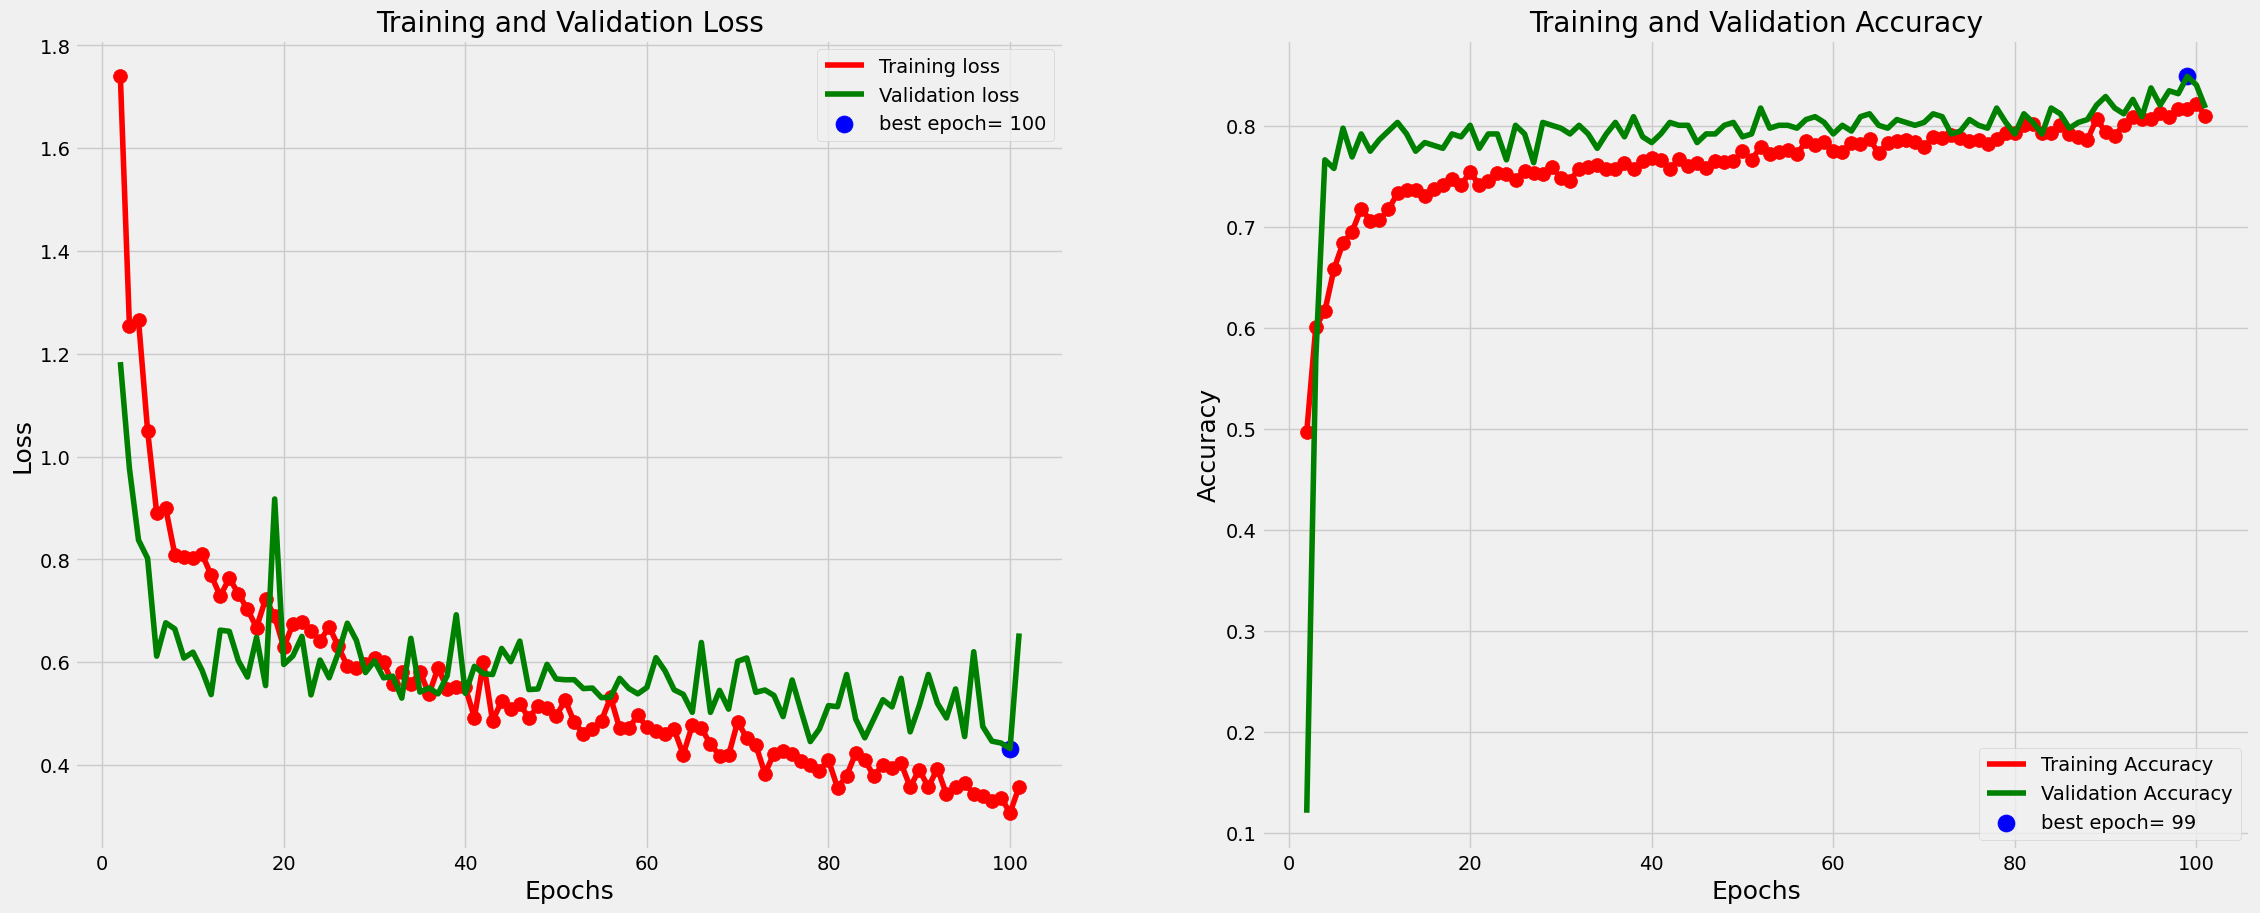

98

In [79]:
tr_plot(history,1)

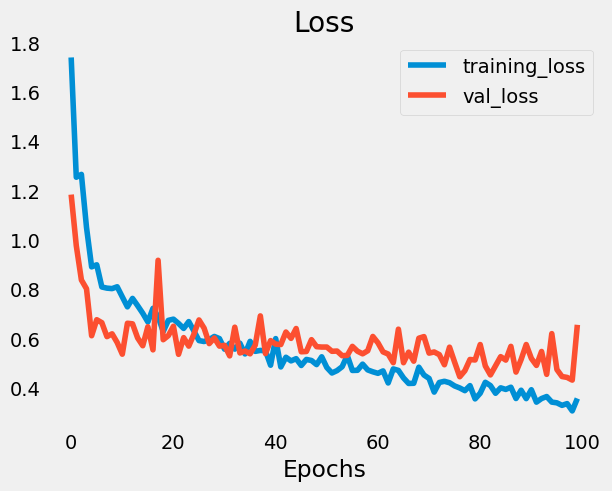

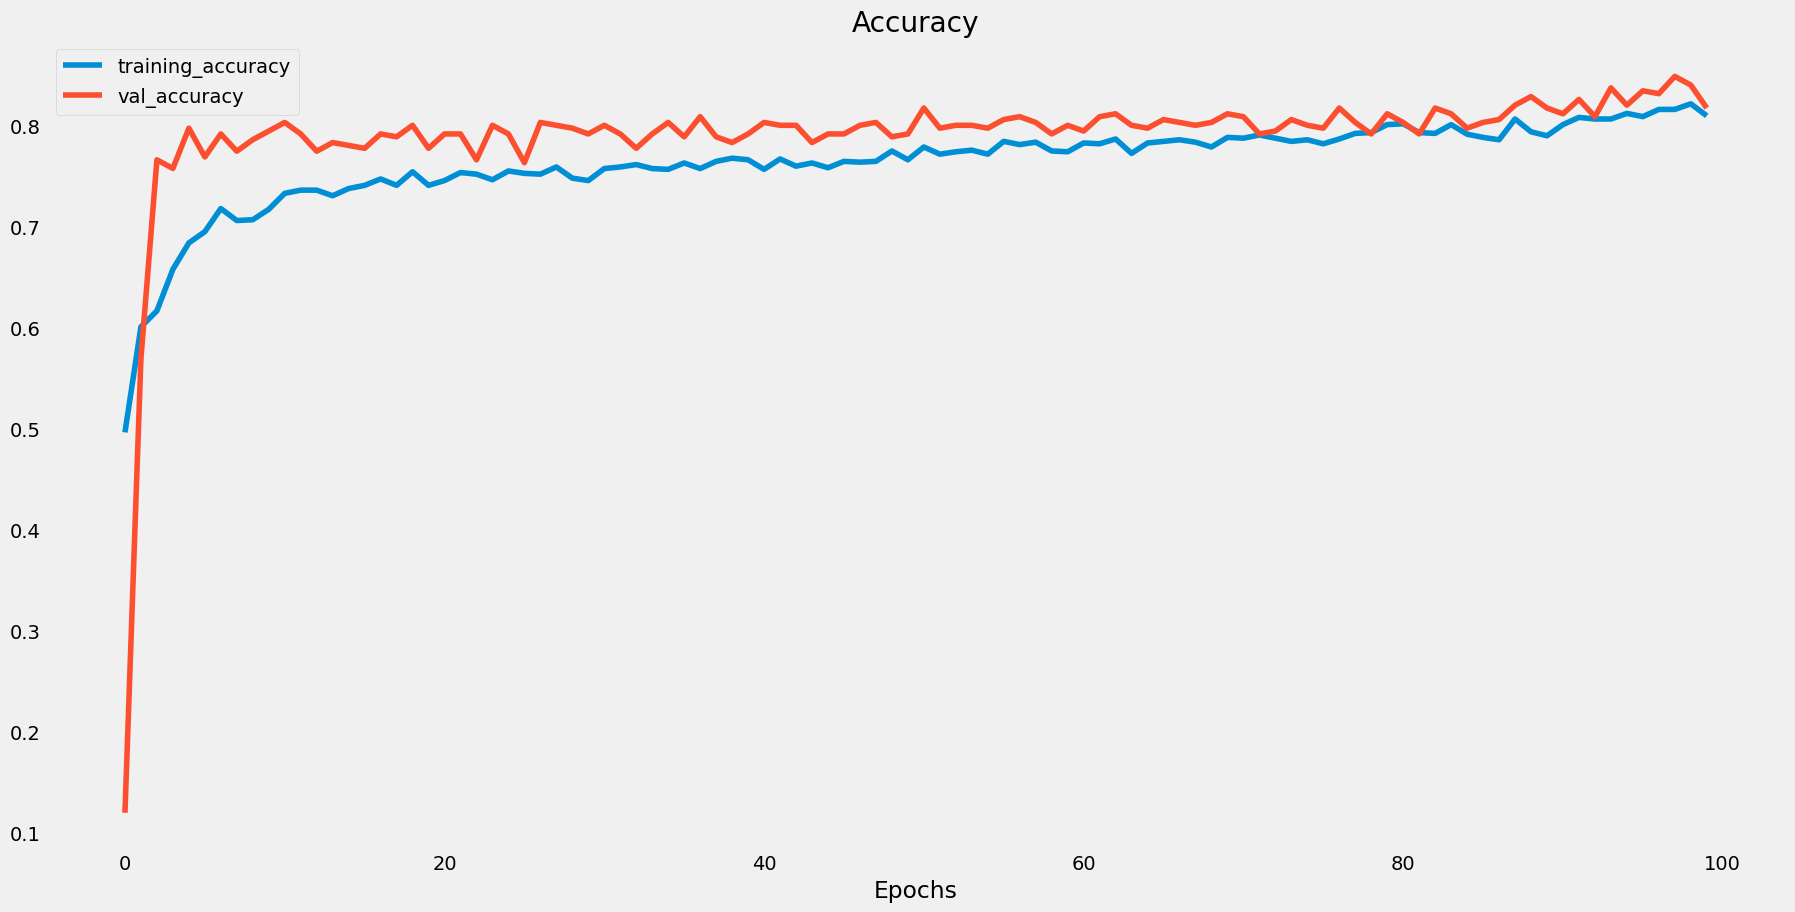

In [80]:
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  Args:
    history: TensorFlow model History object (see: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History)
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()
  plt.grid()


  # Plot accuracy
  plt.figure(figsize=(20,10))
  plt.grid()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

plot_loss_curves(history)

5/5 [==============================] - 0s 58ms/step


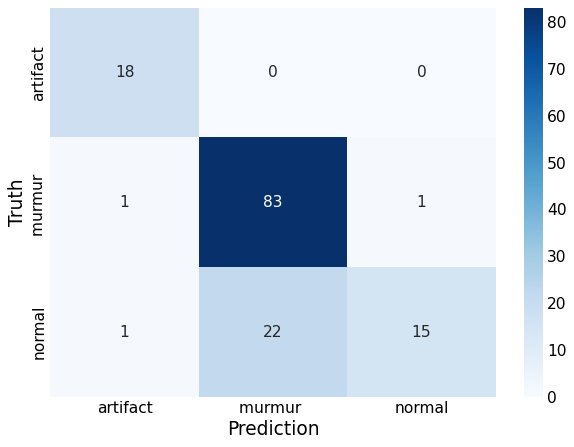

In [81]:

classes = ["artifact" ,"murmur ", "normal"]

preds = hybrid_model.predict(x_test_my)
classpreds = [ np.argmax(t) for t in preds ]
y_testclass = [np.argmax(t) for t in y_test_my]
cm = confusion_matrix(y_testclass, classpreds)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')
ax = sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=classes, yticklabels=classes)

plt.title('')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [ ]:
print(classification_report(y_testclass, classpreds, target_names=classes))


              precision    recall  f1-score   support

    artifact       0.99      1.00      0.99        18
     murmur        0.99      0.98      0.99        85
      normal       0.98      0.97      0.98        38

    accuracy                           0.99       141
   macro avg       0.99      0.98      0.99       141
weighted avg       0.99      0.99      0.99       141

